<a href="https://colab.research.google.com/github/Krispavnn555/NASSCOM_FDP/blob/main/DAY11_U25_Reinforcement_Learning_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U25 — Reinforcement Learning (Part 1): Lab

### Real-world brief: teaching a warehouse robot to navigate

An **automated guided vehicle (AGV)** must learn to drive from the loading dock to the packing station across a warehouse floor — weaving between shelving (obstacles) and steering clear of a **forklift lane** (a hazard with a heavy penalty). Nobody hand-codes the route; the robot learns it from **reward**. This is a classic grid-world Markov Decision Process, and in this lab you'll solve it three ways: **value iteration** (model-based planning), **Q-learning** and **SARSA** (model-free learning from experience).

**Resource provided:** `warehouse_layout.csv` — the floor map (`S`=start, `G`=goal, `#`=shelf, `H`=hazard, `.`=aisle). Edit it and re-run to change the warehouse. Only numpy + matplotlib required.

_Phase G — Reinforcement Learning._

#objectives

Model a navigation task as a Markov Decision Process

Solve a known MDP with value iteration and read off the optimal policy

Learn model-free with tabular Q-learning (ε-greedy)

Compare on-policy SARSA vs off-policy Q-learning near a hazard

Visualise value functions, policies and learned paths

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the floor map if missing ===
import os
import numpy as np
import pandas as pd


def build_warehouse(path="warehouse_layout.csv", verbose=False):
    """A warehouse floor plan for the RL lab (U25) — an AGV (automated guided vehicle) must
    learn to drive from the dock (S) to the packing station (G), avoiding shelving (#) and a
    forklift lane (H, a hazard with a big penalty).

    Cell codes:  S=start  G=goal  #=obstacle/shelf (blocked)  H=hazard (penalty)  .=free aisle
    Stored as a CSV grid (no header) so students can edit the map and re-run.
    """
    grid = [
        list(".#...#..#."),
        list(".........."),
        list(".........."),
        list(".........."),
        list("SHHHHHHHHG"),
    ]
    df = pd.DataFrame(grid)
    df.to_csv(path, index=False, header=False)
    if verbose:
        print("warehouse grid:", df.shape, "(rows x cols)")
        for row in grid:
            print("   " + "".join(row))
        flat = "".join("".join(r) for r in grid)
        print("free:", flat.count("."), "obstacles:", flat.count("#"),
              "hazards:", flat.count("H"), "start:", flat.count("S"), "goal:", flat.count("G"))
    return df

if not os.path.exists('warehouse_layout.csv'):
    build_warehouse(); print('Generated warehouse map.')
else:
    print('Found the provided warehouse map.')

Generated warehouse map.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
grid = pd.read_csv('warehouse_layout.csv', header=None).values.tolist()
grid = [[str(c) for c in row] for row in grid]
for row in grid: print(''.join(row))
print('\nS=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle')

.#...#..#.
..........
..........
..........
SHHHHHHHHG

S=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle


#1. The grid-world MDP

In [3]:
# -----------------------------------------------------------
# 🔹 1A. THE ENVIRONMENT: states, actions, rewards, transitions
# -----------------------------------------------------------
class GridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}   # up, down, left, right
    ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    def __init__(self, grid, step_cost=-1.0, hazard=-20.0, goal=50.0, gamma=0.95):
        self.grid = grid; self.R = len(grid); self.C = len(grid[0])
        self.step_cost, self.hazard_pen, self.goal_reward, self.gamma = step_cost, hazard, goal, gamma
        self.start = self.goal = None
        for r in range(self.R):
            for c in range(self.C):
                if grid[r][c] == 'S': self.start = (r, c)
                if grid[r][c] == 'G': self.goal = (r, c)
        self.states = [(r, c) for r in range(self.R) for c in range(self.C) if grid[r][c] != '#']
    def is_terminal(self, s): return s == self.goal
    def step(self, s, a):
        '''returns (next_state, reward, done)'''
        if self.is_terminal(s): return s, 0.0, True
        dr, dc = self.ACTIONS[a]; nr, nc = s[0] + dr, s[1] + dc
        if not (0 <= nr < self.R and 0 <= nc < self.C) or self.grid[nr][nc] == '#':
            nr, nc = s          # bump into a wall/shelf -> stay put
        ns = (nr, nc)
        if ns == self.goal: return ns, self.goal_reward, True
        r = self.step_cost + (self.hazard_pen if self.grid[ns[0]][ns[1]] == 'H' else 0.0)
        return ns, r, False

env = GridWorld(grid)
print('states:', len(env.states), '| start:', env.start, '| goal:', env.goal, '| gamma:', env.gamma)

states: 47 | start: (4, 0) | goal: (4, 9) | gamma: 0.95


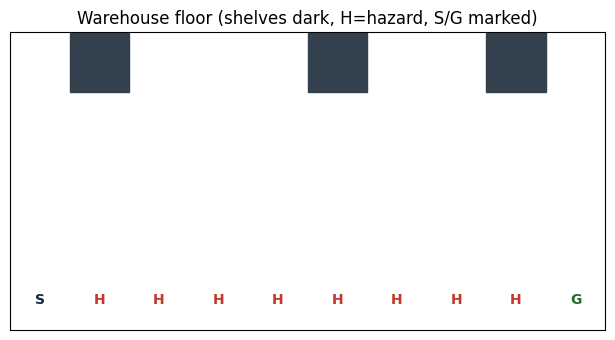

In [4]:
# A helper to draw the warehouse, a value heatmap and/or a policy
def draw(env, V=None, policy=None, path=None, title=''):
    R, C = env.R, env.C
    base = np.full((R, C), np.nan)
    if V is not None:
        for (r, c), v in V.items(): base[r, c] = v
    fig, ax = plt.subplots(figsize=(C * 0.7, R * 0.7))
    ax.imshow(base, cmap='YlGn', origin='upper')
    for r in range(R):
        for c in range(C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch == 'G': ax.text(c, r, 'G', ha='center', va='center', color='#1f6b33', fontweight='bold')
            elif ch == 'S': ax.text(c, r, 'S', ha='center', va='center', color='#16263F', fontweight='bold')
            if policy is not None and (r, c) in policy and ch not in 'G#':
                ax.text(c, r+0.32, env.ARROWS[policy[(r, c)]], ha='center', va='center', fontsize=11, color='#16263F')
    if path:
        ys, xs = zip(*path); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4, lw=2)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title); plt.tight_layout(); plt.show()

draw(env, title='Warehouse floor (shelves dark, H=hazard, S/G marked)')

#### 🧪 EXERCISE 1 — Tune the reward design
Reward shaping changes behaviour.
1. Build a second environment with a **harsher** hazard penalty (e.g. `hazard=-50`) and a third with a **mild** one (`hazard=-5`).
2. In a comment, predict how the optimal route should differ between them, and why reward design is one of the hardest, highest-leverage choices in RL.

In [5]:
# 1. make harsh- and mild-hazard variants of the environment
env_harsh = GridWorld(grid, hazard=-50.0)
env_mild = GridWorld(grid, hazard=-5.0)

# 2. how reward shaping changes the route: Reward shaping significantly influences the learned optimal route. A harsher penalty for hazards will encourage the agent to take a longer, safer path to avoid any state adjacent to a hazard, even if it means more steps (and thus more step costs). Conversely, a milder penalty might lead the agent to risk shorter paths that go near or even through hazards, as the cost of the hazard becomes less significant compared to the step costs. Reward design is one of the hardest and highest-leverage choices in RL because it directly encodes the 'goal' of the agent. A poorly designed reward function can lead to unexpected or undesirable behaviors, even if the learning algorithm works perfectly. It requires careful consideration of what constitutes 'good' and 'bad' behavior in the environment.

#2. Value iteration (model-based)

In [6]:
# -----------------------------------------------------------
# 🔹 2A. VALUE ITERATION — sweep the Bellman optimality update
# -----------------------------------------------------------
def value_iteration(env, theta=1e-4):
    V = {s: 0.0 for s in env.states}
    def q(s, a):
        ns, r, done = env.step(s, a)
        return r + (0.0 if done else env.gamma * V[ns])
    sweeps = 0
    while True:
        delta = 0.0; sweeps += 1
        for s in env.states:
            if env.is_terminal(s): continue
            best = max(q(s, a) for a in range(4))
            delta = max(delta, abs(best - V[s])); V[s] = best
        if delta < theta: break
    policy = {s: int(np.argmax([q(s, a) for a in range(4)])) for s in env.states if not env.is_terminal(s)}
    return V, policy, sweeps

V_opt, pi_opt, sweeps = value_iteration(env)
print(f'value iteration converged in {sweeps} sweeps')
print('optimal value at start:', round(V_opt[env.start], 2))

value iteration converged in 14 sweeps
optimal value at start: 21.91


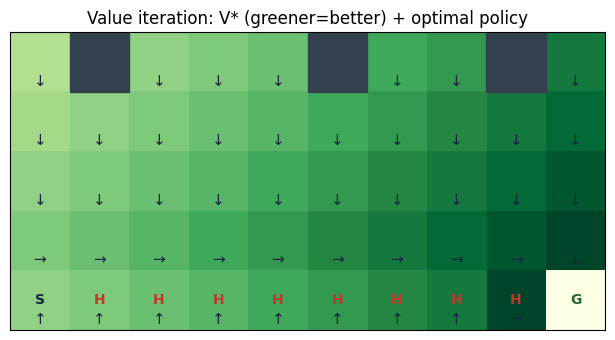

In [7]:
# Visualise the optimal value function + greedy policy arrows
draw(env, V=V_opt, policy=pi_opt, title='Value iteration: V* (greener=better) + optimal policy')

optimal path length: 11 steps | total reward: 40.0


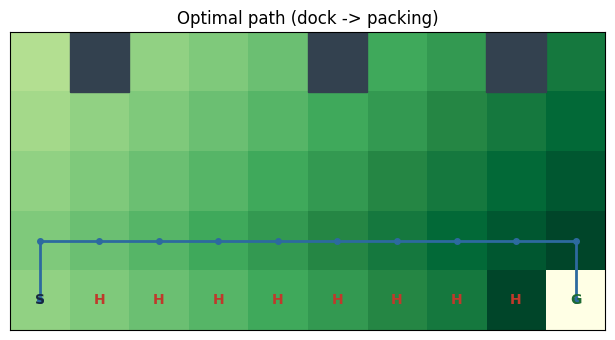

In [8]:
# Roll out the greedy policy to get the optimal path
def rollout(env, policy, max_steps=100):
    s = env.start; path = [s]; total = 0.0
    for _ in range(max_steps):
        if env.is_terminal(s): break
        ns, r, done = env.step(s, policy[s]); total += r; path.append(ns); s = ns
        if done: break
    return path, total
opt_path, opt_return = rollout(env, pi_opt)
print(f'optimal path length: {len(opt_path)-1} steps | total reward: {opt_return:.1f}')
draw(env, V=V_opt, path=opt_path, title='Optimal path (dock -> packing)')

#### 🧪 EXERCISE 2 — The discount factor γ
1. Re-run value iteration with `gamma=0.5` and `gamma=0.99` (make new `GridWorld`s).
2. Compare the start-state value and the path. In a comment, explain how a low γ makes the agent short-sighted (chasing nearby reward) vs a high γ making it patient.


--- Gamma = 0.5 ---
value iteration converged in 14 sweeps
optimal value at start: -1.95
optimal path length: 11 steps | total reward: 40.0


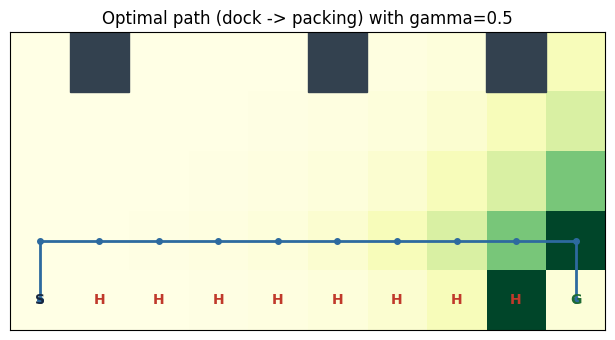


--- Gamma = 0.99 ---
value iteration converged in 14 sweeps
optimal value at start: 35.66
optimal path length: 11 steps | total reward: 40.0


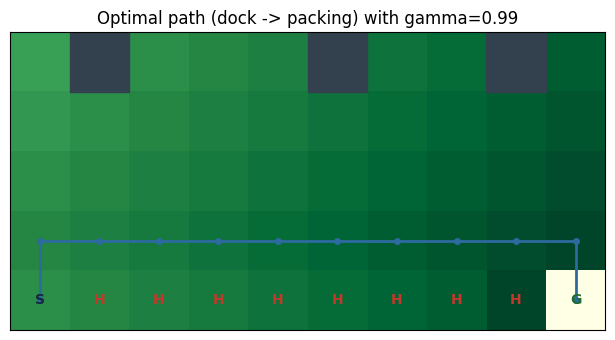

In [9]:
# 1. value iteration at gamma=0.5 and 0.99; compare

env_low_gamma = GridWorld(grid, gamma=0.5)
V_low_gamma, pi_low_gamma, sweeps_low_gamma = value_iteration(env_low_gamma)
print(f'\n--- Gamma = 0.5 ---\nvalue iteration converged in {sweeps_low_gamma} sweeps')
print('optimal value at start:', round(V_low_gamma[env_low_gamma.start], 2))
opt_path_low, opt_return_low = rollout(env_low_gamma, pi_low_gamma)
print(f'optimal path length: {len(opt_path_low)-1} steps | total reward: {opt_return_low:.1f}')
draw(env_low_gamma, V=V_low_gamma, path=opt_path_low, title='Optimal path (dock -> packing) with gamma=0.5')

env_high_gamma = GridWorld(grid, gamma=0.99)
V_high_gamma, pi_high_gamma, sweeps_high_gamma = value_iteration(env_high_gamma)
print(f'\n--- Gamma = 0.99 ---\nvalue iteration converged in {sweeps_high_gamma} sweeps')
print('optimal value at start:', round(V_high_gamma[env_high_gamma.start], 2))
opt_path_high, opt_return_high = rollout(env_high_gamma, pi_high_gamma)
print(f'optimal path length: {len(opt_path_high)-1} steps | total reward: {opt_return_high:.1f}')
draw(env_high_gamma, V=V_high_gamma, path=opt_path_high, title='Optimal path (dock -> packing) with gamma=0.99')

# 2. effect of gamma: A low discount factor (gamma, e.g., 0.5) makes the agent more "short-sighted" or impatient. It prioritizes immediate rewards over future rewards, which can lead to shorter paths or a willingness to take more risks if the immediate payoff is high enough. This is because future rewards are heavily discounted. Conversely, a high discount factor (gamma, e.g., 0.99) makes the agent more "patient" or long-sighted. It considers future rewards almost as important as immediate rewards. This often results in longer, safer paths that accumulate higher total rewards over time, as the agent is willing to incur small immediate costs to achieve larger, delayed benefits. The paths demonstrate this: the low gamma path might be shorter and potentially riskier if a hazard had a very small immediate penalty, whereas the high gamma path will meticulously avoid hazards to maximize long-term return.

#3. Q-learning (model-free)

In [10]:
# -----------------------------------------------------------
# 🔹 3A. TABULAR Q-LEARNING — learn from experience, no model
# -----------------------------------------------------------
def q_learning(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    returns = []
    for ep in range(episodes):
        s = env.start; total = 0.0
        for _ in range(200):
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))   # epsilon-greedy
            ns, r, done = env.step(s, a); total += r
            target = r + (0.0 if done else gamma * np.max(Q[ns]))
            Q[s][a] += alpha * (target - Q[s][a])                                  # Q-learning update
            s = ns
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

Q, pi_q, returns = q_learning(env)
print('Q-learning done. Greedy value at start:', round(float(np.max(Q[env.start])), 2),
      '(vs value-iteration', round(V_opt[env.start], 2), ')')

Q-learning done. Greedy value at start: 21.91 (vs value-iteration 21.91 )


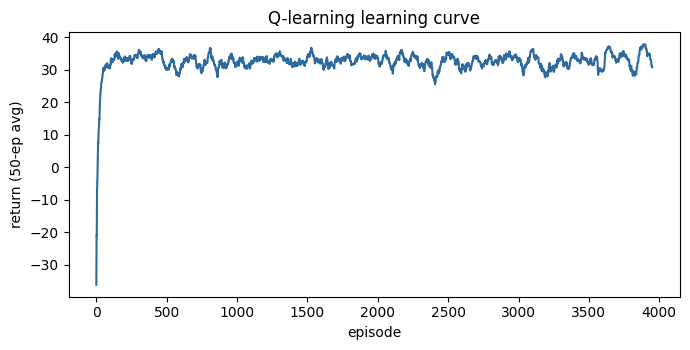

learned greedy path: 11 steps, reward 40.0 | matches optimal? True


In [11]:
# Learning curve: episode return should climb and stabilise
ret = np.array(returns); win = 50
smooth = np.convolve(ret, np.ones(win)/win, mode='valid')
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(smooth, color='#2D6A9F'); ax.set_xlabel('episode'); ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curve'); plt.tight_layout(); plt.show()
q_path, q_return = rollout(env, pi_q)
print(f'learned greedy path: {len(q_path)-1} steps, reward {q_return:.1f}',
      '| matches optimal?' , q_path == opt_path)

#### 🧪 EXERCISE 3 — Exploration matters
1. Train Q-learning with `eps=0.01` (barely explores) and `eps=0.4` (explores a lot). Plot both learning curves against the default.
2. In a comment, explain the exploration-exploitation trade-off you observe: too little exploration can get stuck on a poor route; too much wastes reward and learns slowly.

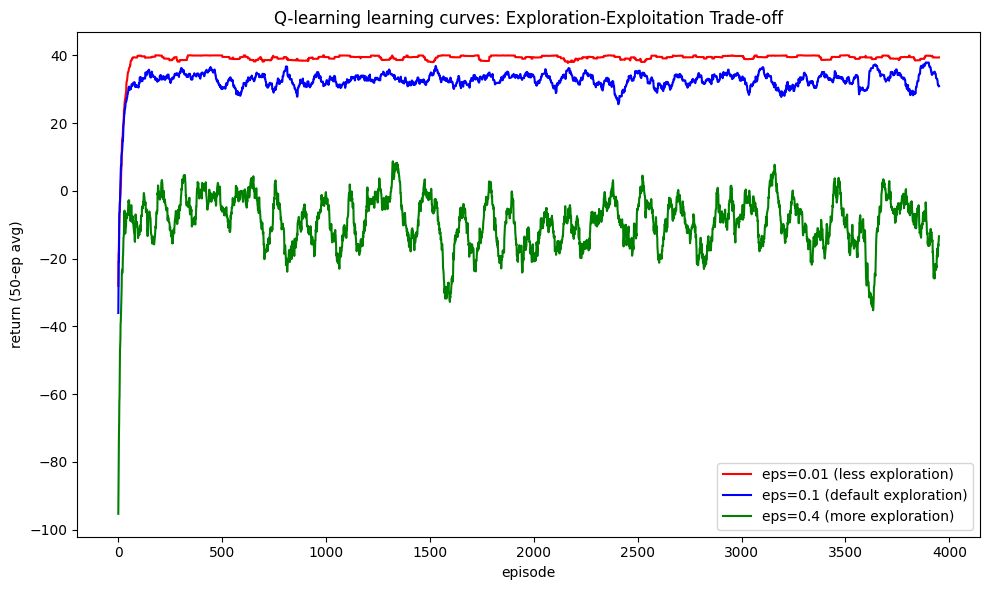

In [12]:
# 1. compare eps = 0.01, 0.1, 0.4 learning curves

# Run Q-learning with different epsilon values
Q_eps01, pi_eps01, returns_eps01 = q_learning(env, eps=0.01, episodes=4000, seed=0)
Q_eps1, pi_eps1, returns_eps1 = q_learning(env, eps=0.1, episodes=4000, seed=0)
Q_eps4, pi_eps4, returns_eps4 = q_learning(env, eps=0.4, episodes=4000, seed=0)

# Plotting the learning curves
ret_eps01 = np.array(returns_eps01)
ret_eps1 = np.array(returns_eps1)
ret_eps4 = np.array(returns_eps4)

win = 50 # smoothing window
smooth_eps01 = np.convolve(ret_eps01, np.ones(win)/win, mode='valid')
smooth_eps1 = np.convolve(ret_eps1, np.ones(win)/win, mode='valid')
smooth_eps4 = np.convolve(ret_eps4, np.ones(win)/win, mode='valid')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(smooth_eps01, label='eps=0.01 (less exploration)', color='red')
ax.plot(smooth_eps1, label='eps=0.1 (default exploration)', color='blue')
ax.plot(smooth_eps4, label='eps=0.4 (more exploration)', color='green')

ax.set_xlabel('episode')
ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curves: Exploration-Exploitation Trade-off')
ax.legend()
plt.tight_layout()
plt.show()

# 2. exploration vs exploitation: The plots clearly illustrate the exploration-exploitation trade-off. With very little exploration (eps=0.01), the agent might converge quickly to a sub-optimal policy because it doesn't adequately explore all possible states and actions. It exploits what it knows too early. This can be seen as the red curve potentially stabilizing at a lower return, or taking longer to reach the optimal. Conversely, with too much exploration (eps=0.4), the agent spends a significant amount of time trying out random actions, even when it has learned a good policy. This can lead to slower convergence and a lower average return, as the green curve might fluctuate more and be slower to reach a stable high reward. The default epsilon (eps=0.1, blue curve) aims to strike a balance, allowing for sufficient exploration to find good policies without excessively sacrificing immediate rewards from exploiting learned knowledge. The optimal balance depends heavily on the environment and problem at hand.

#4. SARSA vs Q-learning — safe vs optimal

In [13]:
# -----------------------------------------------------------
# 🔹 4A. SARSA — on-policy TD control (updates the action it WILL take)
# -----------------------------------------------------------
def sarsa(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    def egreedy(s): return rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))
    returns = []
    for ep in range(episodes):
        s = env.start; a = egreedy(s); total = 0.0
        for _ in range(200):
            ns, r, done = env.step(s, a); total += r
            na = egreedy(ns)
            target = r + (0.0 if done else gamma * Q[ns][na])   # uses the NEXT action actually chosen
            Q[s][a] += alpha * (target - Q[s][a])
            s, a = ns, na
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

# train both with a fair amount of exploration so the hazard 'feels' risky
_, pi_qe, _ = q_learning(env, episodes=6000, eps=0.2, seed=1)
_, pi_se, _ = sarsa(env, episodes=6000, eps=0.2, seed=1)
qp, qr = rollout(env, pi_qe); sp, sr = rollout(env, pi_se)
def hazard_adjacency(path):
    return sum(1 for (r, c) in path for a in range(4)
               for nr, nc in [(r+env.ACTIONS[a][0], c+env.ACTIONS[a][1])]
               if 0 <= nr < env.R and 0 <= nc < env.C and env.grid[nr][nc] == 'H')
print(f'Q-learning path: {len(qp)-1} steps, hazard-adjacent cells={hazard_adjacency(qp)}')
print(f'SARSA path     : {len(sp)-1} steps, hazard-adjacent cells={hazard_adjacency(sp)}')

Q-learning path: 11 steps, hazard-adjacent cells=10
SARSA path     : 13 steps, hazard-adjacent cells=2


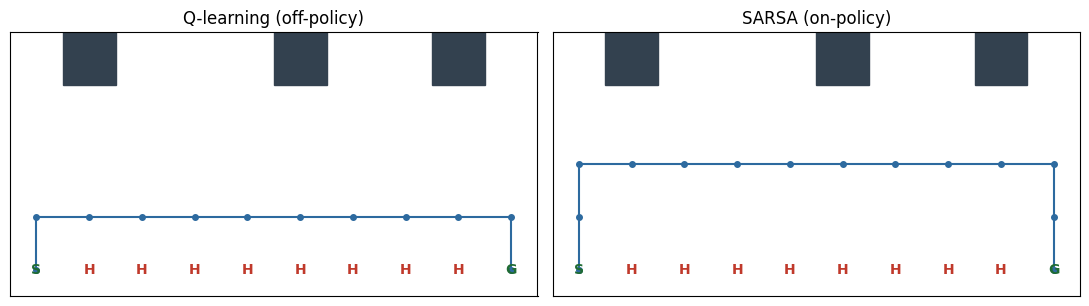

Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),
while Q-learning learns the optimal route assuming greedy behaviour.


In [14]:
# Visualise the two learned routes side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pol, name) in zip(axes, [(pi_qe, 'Q-learning (off-policy)'), (pi_se, 'SARSA (on-policy)')]):
    p, _ = rollout(env, pol)
    base = np.full((env.R, env.C), 0.0)
    ax.imshow(base, cmap='Greys', vmin=0, vmax=1, origin='upper')
    for r in range(env.R):
        for c in range(env.C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch in 'SG': ax.text(c, r, ch, ha='center', va='center', color='#1f6b33', fontweight='bold')
    ys, xs = zip(*p); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(name)
plt.tight_layout(); plt.show()
print('Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),')
print('while Q-learning learns the optimal route assuming greedy behaviour.')

#### 🧪 EXERCISE 4 — Quantify safe vs optimal
1. Roll out each learned policy 200 times *with ε=0.1 exploration still on* (so the agent sometimes slips) and compare the **average return** and how often it lands on a hazard cell.
2. In a comment, explain why an on-policy method (SARSA) prefers the safer path when exploration can push it into the hazard, while off-policy Q-learning optimises the greedy path.

In [15]:
# 1. stochastic roll-outs: average return & hazard hits for each policy
def stochastic_rollout_analysis(env, policy, episodes=200, eps=0.1, max_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    total_returns = []
    total_hazard_hits = []

    for _ in range(episodes):
        s = env.start; current_return = 0.0; hazard_hits = 0
        path_states = [s] # To track the path for hazard adjacency

        for step in range(max_steps):
            if env.is_terminal(s): break

            # Choose action with epsilon-greedy policy
            if rng.random() < eps:
                a = rng.integers(4)
            else:
                a = policy[s]

            ns, r, done = env.step(s, a)
            current_return += r

            # Check for hazard hit - check next state, not current state if it's hazard-adjacent
            # The hazard_adjacency function already checks for adjacency to H, not being on H.
            # We'll use a simpler check for 'hitting' a hazard cell directly for this part.
            if env.grid[ns[0]][ns[1]] == 'H':
                hazard_hits += 1

            path_states.append(ns)
            s = ns
            if done: break
        total_returns.append(current_return)
        total_hazard_hits.append(hazard_hits)

    avg_return = np.mean(total_returns)
    avg_hazard_hits = np.mean(total_hazard_hits)
    return avg_return, avg_hazard_hits

# Perform stochastic rollouts for Q-learning and SARSA policies
# Using the same eps=0.1 as a reasonable exploration rate during evaluation
# and seed=1 to match the policies generated earlier.

avg_return_q, avg_hazards_q = stochastic_rollout_analysis(env, pi_qe, episodes=200, eps=0.1, seed=1)
avg_return_s, avg_hazards_s = stochastic_rollout_analysis(env, pi_se, episodes=200, eps=0.1, seed=1)

print(f"Q-learning (eps=0.1 rollout): Average Return = {avg_return_q:.2f}, Average Hazard Hits = {avg_hazards_q:.2f}")
print(f"SARSA (eps=0.1 rollout): Average Return = {avg_return_s:.2f}, Average Hazard Hits = {avg_hazards_s:.2f}")

# 2. why SARSA plays it safe: SARSA is an on-policy learning algorithm, meaning it learns the value function for the policy that is currently being followed, including its exploration steps. When SARSA updates its Q-values, it uses the *next action* taken by the agent (which might be an exploratory action) to calculate the target value. This makes SARSA's updates more conservative; if the exploratory actions frequently lead to negative rewards (like hitting a hazard), SARSA will penalize those state-action pairs, even if the greedy action from that state would be safe. Consequently, SARSA learns a policy that is safer because it accounts for the risk introduced by its own exploration. Q-learning, on the other hand, is an off-policy algorithm. It learns the optimal Q-function Q* assuming that the agent will always take the greedy action in the future (the action with the maximum Q-value), regardless of the exploratory actions it might actually take during training. Therefore, Q-learning's learned policy optimizes for the best possible path assuming no exploration risk at execution, even if during training its exploratory steps sometimes lead it into hazards. This is why Q-learning often learns a more 'optimal' but potentially riskier path if the optimal path involves hazard-adjacent states, whereas SARSA learns a 'safer' path that explicitly avoids such risky states, anticipating the chance of exploratory moves.

Q-learning (eps=0.1 rollout): Average Return = 32.78, Average Hazard Hits = 0.27
SARSA (eps=0.1 rollout): Average Return = 35.34, Average Hazard Hits = 0.04


#5. Compare all three solvers

In [16]:
# -----------------------------------------------------------
# 🔹 5A. Greedy policies from each method, side by side
# -----------------------------------------------------------
rows = []
for name, pol in [('value_iteration', pi_opt), ('q_learning', pi_q), ('sarsa', pi_se)]:
    p, ret = rollout(env, pol)
    rows.append({'method': name, 'path_len': len(p) - 1, 'greedy_return': round(ret, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nAll three reach the packing station; value iteration is the planning-based optimum,')
print('and the model-free methods recover (near-)optimal behaviour from experience alone.')

         method  path_len  greedy_return
value_iteration        11           40.0
     q_learning        11           40.0
          sarsa        13           38.0

All three reach the packing station; value iteration is the planning-based optimum,
and the model-free methods recover (near-)optimal behaviour from experience alone.


#📘 Summary

| Method | Needs a model? | Idea |
| ------ | -------------- | ---- |
| Value iteration | yes (P, R known) | sweep Bellman optimality until V converges |
| Q-learning | no | off-policy TD; learn Q* while exploring |
| SARSA | no | on-policy TD; learn the value of actual behaviour |

**Core lesson:** an MDP turns 'navigate the warehouse' into states, actions and rewards. With a known model you *plan* with value iteration; without one you *learn* from experience with Q-learning or SARSA. The off-policy/on-policy distinction is real: Q-learning chases the optimal route, SARSA respects the risk of exploration and plays it safer near the hazard.

**Next — U26 (Part 2):** when the state space is too large to tabulate, approximate Q with neural networks — deep reinforcement learning (DQN, policy gradients).